In [1]:
# تثبيت مكتبة يولو واستيراد الأدوات المطلوبة
print("جاري تثبيت المكتبات وإعداد البيئة...")
!pip install -q ultralytics

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO
import requests
from io import BytesIO
print("تم الانتهاء من التثبيت بنجاح!")

جاري تثبيت المكتبات وإعداد البيئة...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
تم الانتهاء من التثبيت بنجاح!


In [2]:
# تحميل صورة لاعب كرة سلة من الإنترنت
image_url = "https://images.unsplash.com/photo-1546519638-68e109498ffc?q=80&w=1000&auto=format&fit=crop"
response = requests.get(image_url)
input_image = Image.open(BytesIO(response.content)).convert("RGB")

image_path = "basketball_player.jpg"
input_image.save(image_path)

# تحميل موديل YOLO26 وتشغيل التنبؤ (Inference)
model = YOLO("yolo26n.pt")
CONFIDENCE_THRESHOLD = 0.45  # نسبة الثقة المخصصة

results = model(image_path, conf=CONFIDENCE_THRESHOLD)
result = results[0]
print("تم تشغيل نموذج YOLO بنجاح!")


image 1/1 /content/basketball_player.jpg: 448x640 1 sports ball, 355.7ms
Speed: 14.1ms preprocess, 355.7ms inference, 6.8ms postprocess per image at shape (1, 3, 448, 640)
تم تشغيل نموذج YOLO بنجاح!


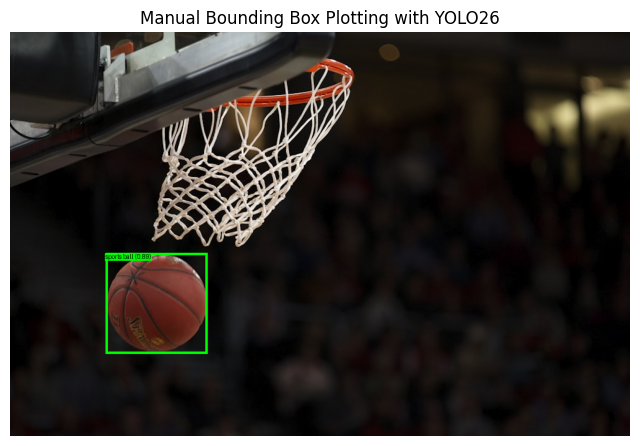

In [3]:
# نسخ الصورة للرسم عليها يدوياً
draw_image = input_image.copy()
draw = ImageDraw.Draw(draw_image)

detected_objects = []

# استخراج الإحداثيات والنتائج
boxes = result.boxes.xyxy.cpu().numpy()
scores = result.boxes.conf.cpu().numpy()
classes = result.boxes.cls.cpu().numpy()
names = result.names

for box, score, cls_id in zip(boxes, scores, classes):
    if score >= CONFIDENCE_THRESHOLD:
        x1, y1, x2, y2 = map(int, box)
        class_name = names[int(cls_id)]

        detected_objects.append({"class": class_name, "confidence": float(score)})

        # رسم المستطيل يدوياً
        draw.rectangle([x1, y1, x2, y2], outline="lime", width=4)

        # كتابة اسم الكائن ونسبة الثقة فوق العنصر
        label_text = f"{class_name} ({score:.2f})"
        try:
            font = ImageFont.truetype("usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
        except IOError:
            font = ImageFont.load_default()

        text_bbox = draw.textbbox((x1, y1), label_text, font=font)
        draw.rectangle(text_bbox, fill="lime")
        draw.text((x1, y1), label_text, fill="black", font=font)

# عرض الصورة الناتجة
plt.figure(figsize=(8, 8))
plt.imshow(draw_image)
plt.axis("off")
plt.title("Manual Bounding Box Plotting with YOLO26")
plt.show()

In [4]:
def generate_scene_summary(objects):
    if not objects:
        return "لم يتم اكتشاف أي كائنات تتجاوز نسبة الثقة المحددة."

    class_counts = {}
    for obj in objects:
        c_name = obj["class"]
        class_counts[c_name] = class_counts.get(c_name, 0) + 1

    summary_sentences = []
    for c_name, count in class_counts.items():
        if count == 1:
            prefix = "An" if c_name.lower()[0] in 'aeiou' else "A"
            summary_sentences.append(f"{prefix} {c_name}")
        else:
            summary_sentences.append(f"{count} {c_name}s")

    if len(summary_sentences) == 1:
        content_desc = summary_sentences[0]
    elif len(summary_sentences) == 2:
        content_desc = f"{summary_sentences[0]} and {summary_sentences[1]}"
    else:
        content_desc = ", ".join(summary_sentences[:-1]) + f", and {summary_sentences[-1]}"

    summary = (
        f"Scene Analysis Report:\n"
        f"The custom object detection pipeline successfully analyzed the input frame using Ultralytics YOLO26. "
        f"With a confidence threshold set above {CONFIDENCE_THRESHOLD * 100}%, the model identified: "
        f"{content_desc}. Each detected item has been bounded and labeled programmatically."
    )
    return summary

print("="*50)
print("AUTOMATED IMAGE CONTENT DESCRIPTION SCRIPT")
print("="*50)
print(generate_scene_summary(detected_objects))

AUTOMATED IMAGE CONTENT DESCRIPTION SCRIPT
Scene Analysis Report:
The custom object detection pipeline successfully analyzed the input frame using Ultralytics YOLO26. With a confidence threshold set above 45.0%, the model identified: A sports ball. Each detected item has been bounded and labeled programmatically.
